In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
################
# aa codon table
codon_dic_updated = {
                'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
                'TCT': "S'", 'TCC': "S'", 'TCA': "S'", 'TCG': "S'",
                'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',  # * for STOP
                'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',

                'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
                'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
                'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
                'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',

                'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
                'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
                'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
                'AGT': 'S"', 'AGC': 'S"', 'AGA': 'R', 'AGG': 'R',

                'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
                'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
                'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
                'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
                }

aa_list = ["F", "L", "S'", "Y", "*", 
           "C", "W", "P", "H", "Q", 
           "R", "I", "M", "T", "N", 
           "K", 'S"', "R", "V", "A", 
           "D", "E", "G"]

#########################
# Translating nt sequence
def nt_transalte_104(nt_seq):
    rem3 = len(nt_seq) % 3

    if rem3 != 0:
        nt_seq = nt_seq[:-rem3]

    translated = []
    seq_len = len(nt_seq)

    for i in range(1, int((seq_len+3)/3)):
        codon = nt_seq[i*3-3:i*3]
    
        if codon in list(codon_dic_updated.keys()):
            aa = codon_dic_updated[codon]  
        else:
            aa = "-"
            
        translated.append(aa)
    
    return translated

########################################################
# Mnapping sequences from S', S" -> S , and removing "-"
def clean_array(arr):
    arr = np.asarray(arr)
    arr = np.where(np.isin(arr, ["S'", 'S"']), "S", arr)
  
    return arr[arr != "-"]


###############################################
# Counting simillar values at indexes per array
def compare_seqs(seqA : list,
                 SeqB : list):
    
    same_length = (len(seqA) == len(SeqB))

    if same_length is False:
        return 0
    
    df = pd.DataFrame({"seqA":seqA, "seqB":SeqB})
    score = (df.seqA == df.seqB).sum() / len(seqA)

    return score


##########################################
# Couting common values beteween two lists
def inter_motif(seq:str, 
                motif:list,
                cutoff = 0.8) -> bool:
    # Defining sequence and motifs
    seq_clean = clean_array(seq)
    motif_clean = [clean_array(i) for i in motif]

    try:
        inter_val = [float(compare_seqs(seq_clean, i)) for i in motif_clean]
            
        if any(val >= cutoff for val in inter_val):
            return 1
    
        else:
            return 0
    
    except:
        return 0

* When cheeking for preservation -> compare to the germline sequence
* finish baseline

In [3]:
# Sequences path & dataframe object
seqs_path = os.path.join("trimers_processed_tables", "cleaned_seqs.csv")
seqs_df = pd.read_csv(seqs_path, index_col=0)

if False:
    # Metadata metadata mapping
    seqs_df["time_point"] = seqs_df["time_point"].apply(lambda X : X[0])
    seqs_df["ab_target"] = seqs_df["ab_target"].map({"Non-Spike B":"sn", "Spike+ Mem B":"sp"})
    seqs_df["subject_id"] = "subj_" + seqs_df.subject_id.astype("str")

# https://www.imgt.org/IMGTrepertoire/Proteins/proteinDisplays.php?species=human&latin=Homo%20sapiens&group=IGHV
# genetic motifs:
motif_a = ["V", "A", "V", "I", "S'", "Y", "D", "-", "-", 'G', 'S"', "N", "K", "Y"]
motif_b = ["V", "A", "V", "I", "W", "Y", "D", "-", "-", 'G', 'S"', "N", "K", "Y"]
motif_ab = ["".join(i) for i in [motif_a, motif_a]]

# Setting fresh copy of the dataframe
seqs_cleaned = seqs_df.copy()

# Getting the top sequence rows only
idx = seqs_cleaned.groupby('clone_id')['copy_number'].idxmax()
seqs_cleaned = seqs_cleaned.loc[idx,:]

# Metadata metadata mapping
seqs_cleaned["time_point"] = seqs_cleaned["time_point"].apply(lambda X : X[0])
seqs_cleaned["ab_target"] = seqs_cleaned["ab_target"].map({"Non-Spike B":"sn", "Spike+ Mem B":"sp"})
seqs_cleaned["subject_id"] = "subj_" + seqs_cleaned.subject_id.astype("str")
seqs_cleaned = seqs_cleaned[["clone_id", "sequence", "germline", "copy_number", "subject_id", "ab_target", "time_point"]]

# Translating both germline and top sequence to amino acids
seqs_cleaned["germ_aa"] = seqs_cleaned["germline"].apply(lambda X : np.array(nt_transalte_104(X)))
seqs_cleaned["seq_aa"] = seqs_cleaned["sequence"].apply(lambda X : np.array(nt_transalte_104(X)))

# Getting the relevent motif aa sequence (54-66): VAV ISYD..GSNK Y
seqs_cleaned["germ_5366"] = seqs_cleaned["germ_aa"].apply(lambda X : X[52:66])
seqs_cleaned["seq_5366"] = seqs_cleaned["seq_aa"].apply(lambda X : X[52:66])


# Selecting only relevent columns
seqs_cleaned = seqs_cleaned[["clone_id", "germ_aa", "seq_aa", "germ_5366", "seq_5366", "subject_id", "ab_target", "time_point"]]

# Adding labels per clone (top sequence)
seqs_cleaned["label_s"] = seqs_cleaned.ab_target + "." + seqs_cleaned.time_point.astype("str")
seqs_cleaned["label_l"] = seqs_cleaned["label_s"] + "." + seqs_cleaned.subject_id.astype("str")

# Dropping subject 7
seqs_cleaned = seqs_cleaned[seqs_cleaned.label_l.str.split(".").apply(lambda X : X[-1]) != "subj_7"]

In [4]:
# Comparing the germline and somatic 53-66 sequence to the motifs
seqs_cleaned.loc[seqs_cleaned["germ_5366"].str.join("").isin(motif_ab), "germ_motif"] = 1
seqs_cleaned.loc[seqs_cleaned["seq_5366"].str.join("").isin(motif_ab), "seq_motif"] = 1
seqs_cleaned.loc[seqs_cleaned["germ_motif"] == 1, "seq_motif_80p"] = seqs_cleaned["seq_5366"].apply(lambda X: inter_motif(np.array(X), [motif_a, motif_b]))
seqs_cleaned.loc[seqs_cleaned["germ_motif"] == 1, "seq_motif_100p"] = seqs_cleaned["seq_5366"].apply(lambda X: inter_motif(np.array(X), [motif_a, motif_b], 1))
seqs_cleaned.fillna(0, inplace=True)


In [9]:
seqs_cleaned["seq_motif_80p"].value_counts()

seq_motif_80p
0.0    60611
1.0     2283
Name: count, dtype: int64

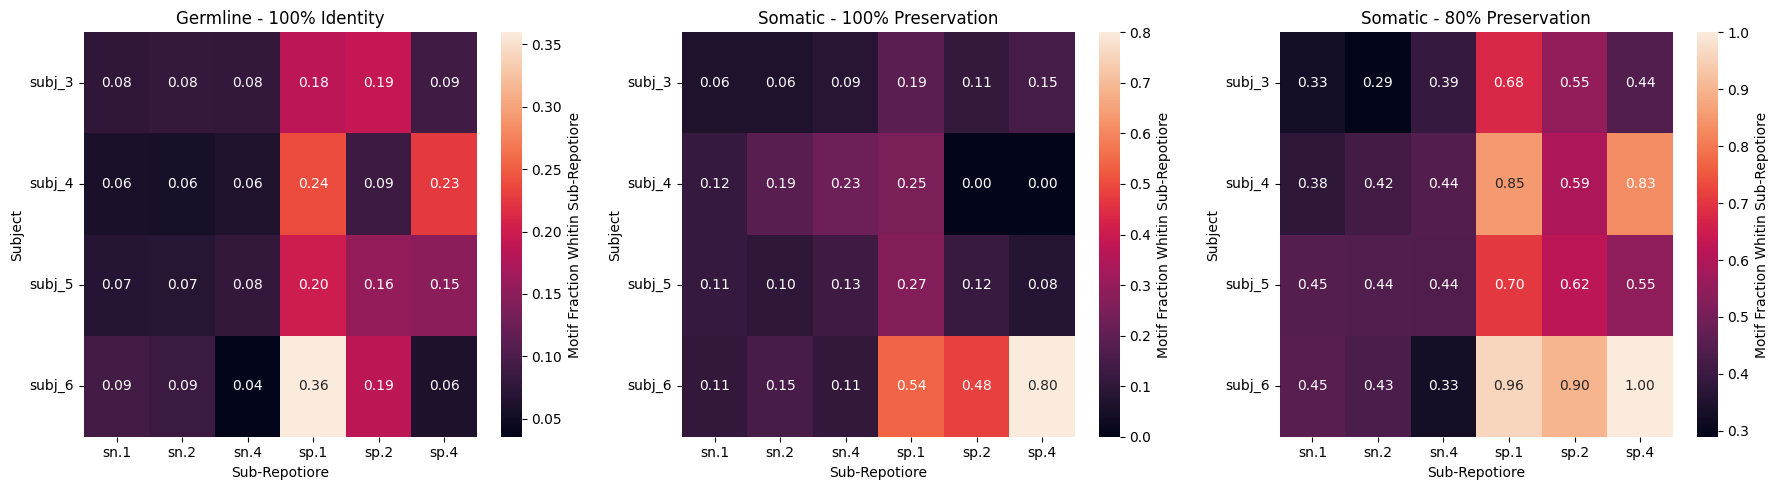

In [12]:
# Visualization

label_dict = {"germ_motif":"Germline - 100% Identity", 
              "seq_motif_100p":"Somatic - 100% Preservation",
              "seq_motif_80p":"Somatic - 80% Preservation"}

fig, axs = plt.subplots(1, 3, figsize=(18,5))

unique_subjects, unique_labels = seqs_cleaned.subject_id.unique(), seqs_cleaned.label_s.unique()
result_freqs = pd.DataFrame(index=unique_subjects, columns= unique_labels)
conditions = [(i,j) for i in np.sort(unique_subjects) for j in np.sort(unique_labels)]
cleaned_seq_motif = seqs_cleaned[seqs_cleaned.germ_motif == 1]
metric = "frac"


for i,j in zip([["germ_motif",seqs_cleaned], ["seq_motif_100p",cleaned_seq_motif],["seq_motif_80p",cleaned_seq_motif]], (0,1,2)):
    source = i[0]
    ax = axs[j]
    i_df = i[1]

    for cnd in conditions:
        temp_series =  i_df.loc[(i_df.subject_id == cnd[0]) & (i_df.label_s == cnd[1]), source]

        if len(temp_series) == 0:
            result_freqs.loc[cnd[0], cnd[1]] = np.nan
        
        else:
            if metric == "count":
                result_freqs.loc[cnd[0], cnd[1]] = temp_series.sum()
            
            elif metric == "frac":
                result_freqs.loc[cnd[0], cnd[1]] = temp_series.sum()/len(temp_series)


    result_freqs = result_freqs.astype("float")[np.sort(result_freqs.columns)]

    sns.heatmap(result_freqs, 
                ax=ax, 
                cbar_kws={'label': 'Motif Fraction Whitin Sub-Repotiore'},
                annot=True,
                fmt='.2f')
    
    
    ax.set_title(label_dict[i[0]])
    ax.tick_params(axis='y', labelrotation=0)
    ax.set_xlabel("Sub-Repotiore")
    ax.set_ylabel("Subject")

plt.tight_layout()
plt.show()
